# Deterministic Radiomap Single Cube

This notebook builds a single cube at the scene center, places an elevated transmitter left of the y-axis, enables first-order diffraction, and renders the scene layout, deterministic radio-map component views, and y = +/-4 power-line diagnostics.


In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

repo_root = Path.cwd().resolve()
if not (repo_root / "witwin").exists():
    repo_root = next(path for path in repo_root.parents if (path / "witwin").exists())
repo_root_str = str(repo_root)
sys.path = [path for path in sys.path if str(Path(path or ".").resolve()) != repo_root_str]
sys.path.insert(0, repo_root_str)

importlib.invalidate_caches()
for module_name in tuple(sys.modules):
    if module_name == "witwin" or module_name.startswith((
        "examples.deterministic_radiomap_single_cube",
        "witwin.",
    )):
        sys.modules.pop(module_name, None)

import examples.deterministic_radiomap_single_cube as single_cube

figure_dir = repo_root / "examples"
layout_path = figure_dir / "deterministic_radiomap_single_cube_layout.png"
forward_path = figure_dir / "deterministic_radiomap_single_cube_forward.png"
components_path = figure_dir / "deterministic_radiomap_single_cube_components.png"
line_profiles_path = figure_dir / "deterministic_radiomap_single_cube_yline_profiles.png"

experiment = single_cube.SingleCubeExperiment(
    grid_shape=(256, 256),
    forward_num_samples=192,
    max_bounces=2,
    max_diffraction_order=1,
    shadow_boundary_correction=False,
)

display({
    "cube_center_m": experiment.cube_center,
    "tx_pos_m": experiment.tx_pos,
    "receiver_plane_z_m": experiment.plane_z,
    "grid_shape": experiment.grid_shape,
    "enable_rd_diffraction": experiment.forward_config.tuning.enable_rd_diffraction,
    "max_diffraction_order": experiment.forward_config.max_diffraction_order,
})


jitc_llvm_init(): LLVM API initialization failed ..


{'cube_center_m': (0.0, 0.0, 1.5),
 'tx_pos_m': (-2.0, -5.0, 4.0),
 'receiver_plane_z_m': 1.0,
 'grid_shape': (256, 256),
 'enable_rd_diffraction': True,
 'max_diffraction_order': 1}

## Scene Layout


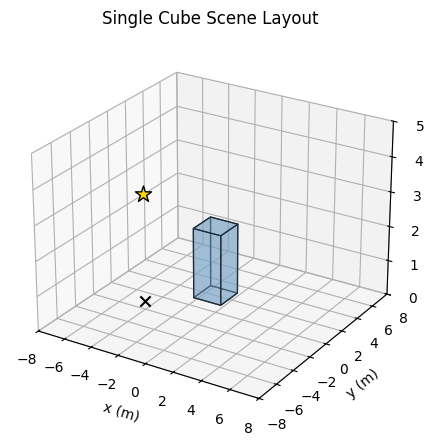

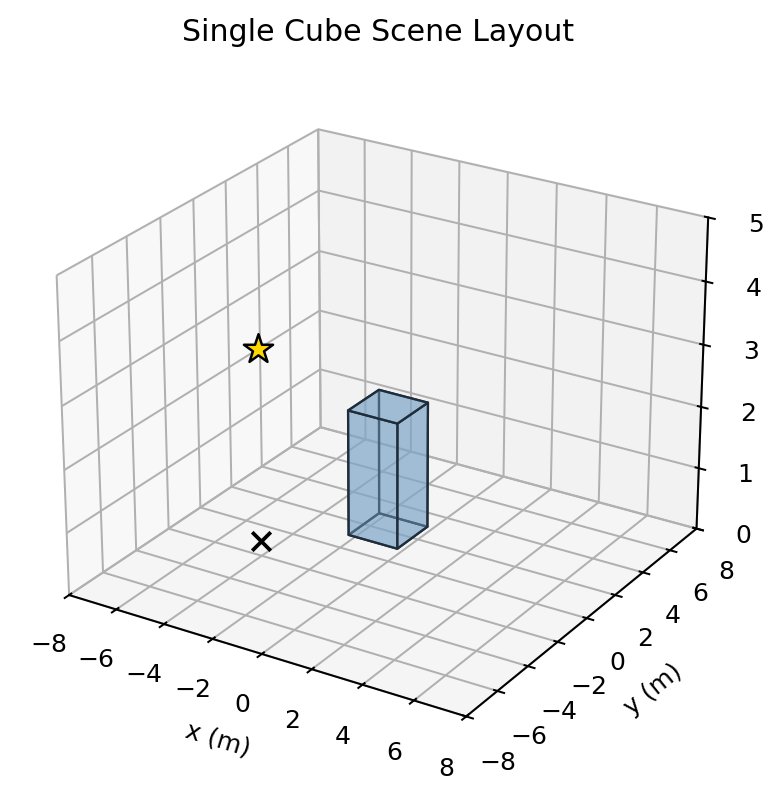

In [2]:
ax = single_cube.plot_scene_layout(experiment)
ax.figure.savefig(layout_path, dpi=180, bbox_inches="tight")
plt.show()

display(Image(filename=str(layout_path)))


## Deterministic Solve


In [3]:
snapshot = experiment.forward()
line_profiles = single_cube.line_power_profiles(snapshot, y_values=(-4.0, 4.0))
summary = {
    "path_gain_shape": snapshot.path_gain.shape,
    "path_gain_finite": bool(np.isfinite(snapshot.path_gain).all()),
    "path_gain_max": float(np.max(snapshot.path_gain)),
    "component_max": {
        name: float(np.max(values))
        for name, values in snapshot.components.items()
    },
    "line_profiles": single_cube.summarize_line_power_profiles(line_profiles),
}
display(summary)


{'path_gain_shape': (256, 256),
 'path_gain_finite': True,
 'path_gain_max': 9.261871309718117e-05,
 'component_max': {'los': 6.322441913653165e-05,
  'reflection': 2.0931734979967587e-05,
  'diffraction': 1.6326472177752294e-05},
 'line_profiles': {'y=-4': {'sampled_y': -4.03125,
   'row_index': 63,
   'path_gain_max_db': -42.08521316656906,
   'path_gain_mean_db': -45.59085461257196,
   'component_max_db': {'los': -42.42140735966082,
    'reflection': -50.508425879158104,
    'diffraction': -52.427855527184164},
   'component_mean_db': {'los': -45.760420439119585,
    'reflection': -57.73780831159141,
    'diffraction': -62.2324570564392},
   'component_fraction_mean': {'los': 0.9341289839612902,
    'reflection': 0.047498433938682964,
    'diffraction': 0.018372582100026888},
   'component_nonzero_fraction': {'los': 1.0,
    'reflection': 0.21875,
    'diffraction': 0.58984375}},
  'y=4': {'sampled_y': 3.96875,
   'row_index': 191,
   'path_gain_max_db': -48.537432958066105,
   'pat

## Rendered Maps


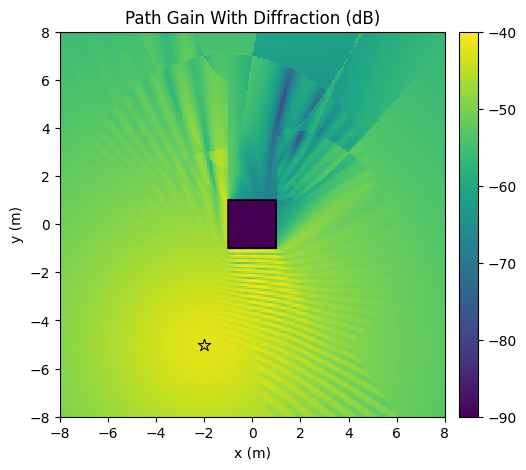

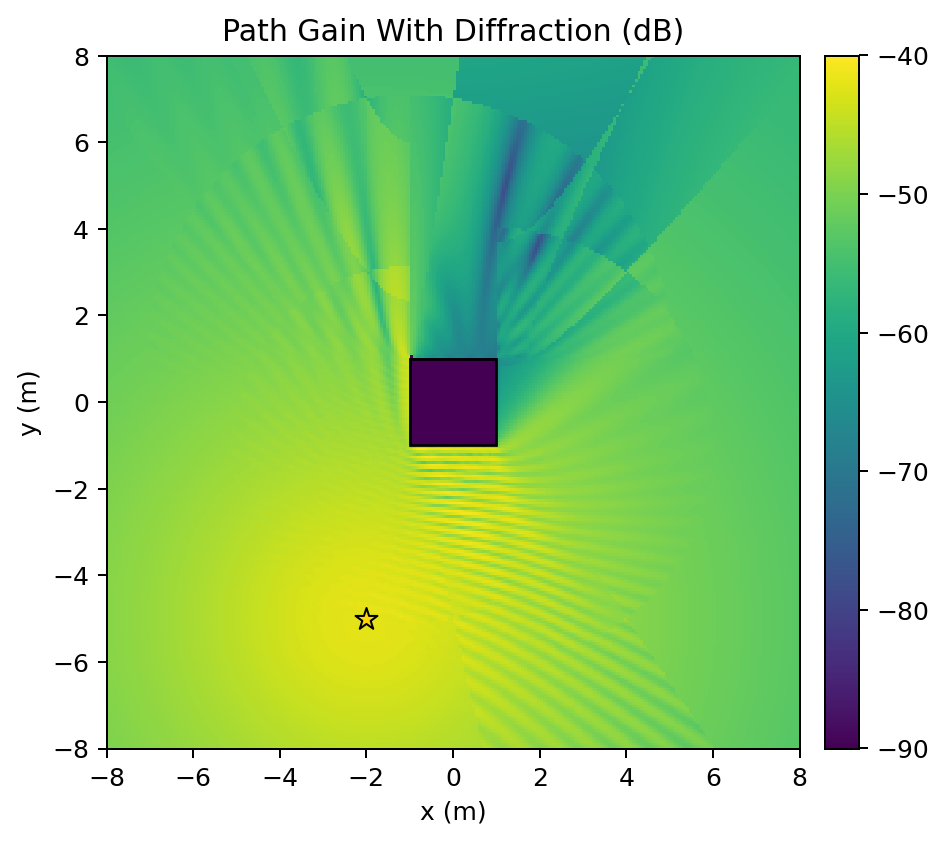

In [4]:
ax = single_cube.plot_forward(snapshot, experiment=experiment)
ax.figure.savefig(forward_path, dpi=180, bbox_inches="tight")
plt.show()

display(Image(filename=str(forward_path)))


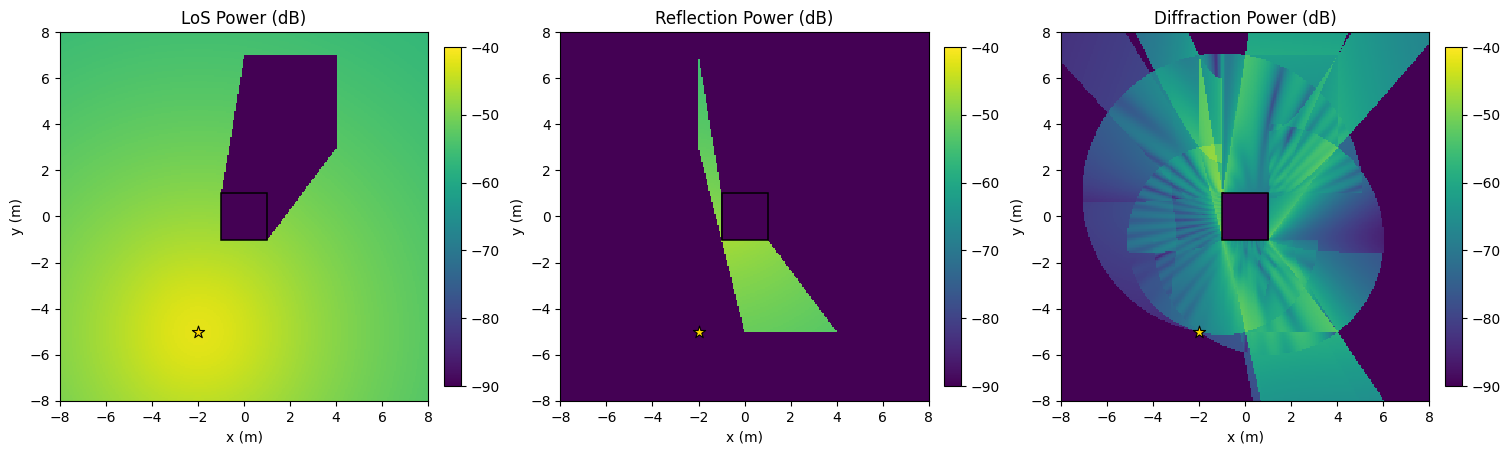

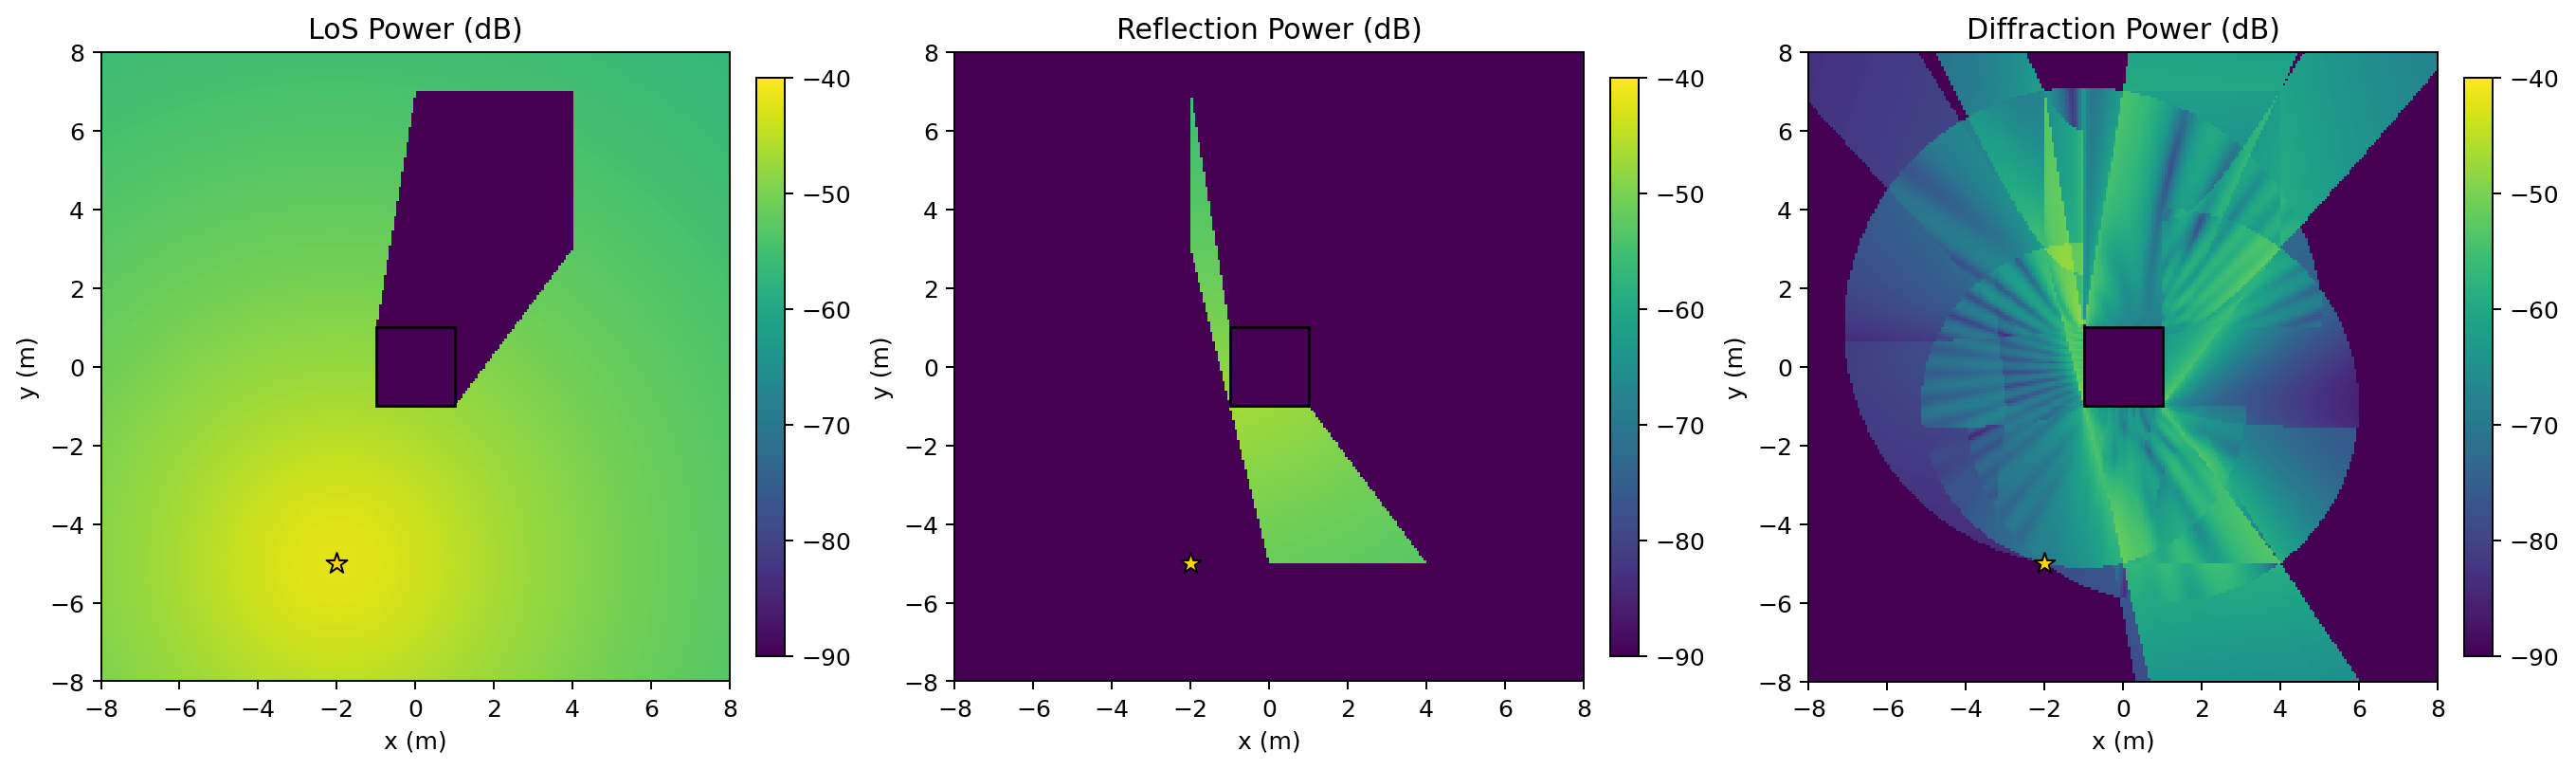

In [5]:
axes = single_cube.plot_forward_components(snapshot, experiment=experiment)
axes[0].figure.savefig(components_path, dpi=180, bbox_inches="tight")
plt.show()

display(Image(filename=str(components_path)))


## y = +/-4 Power Lines


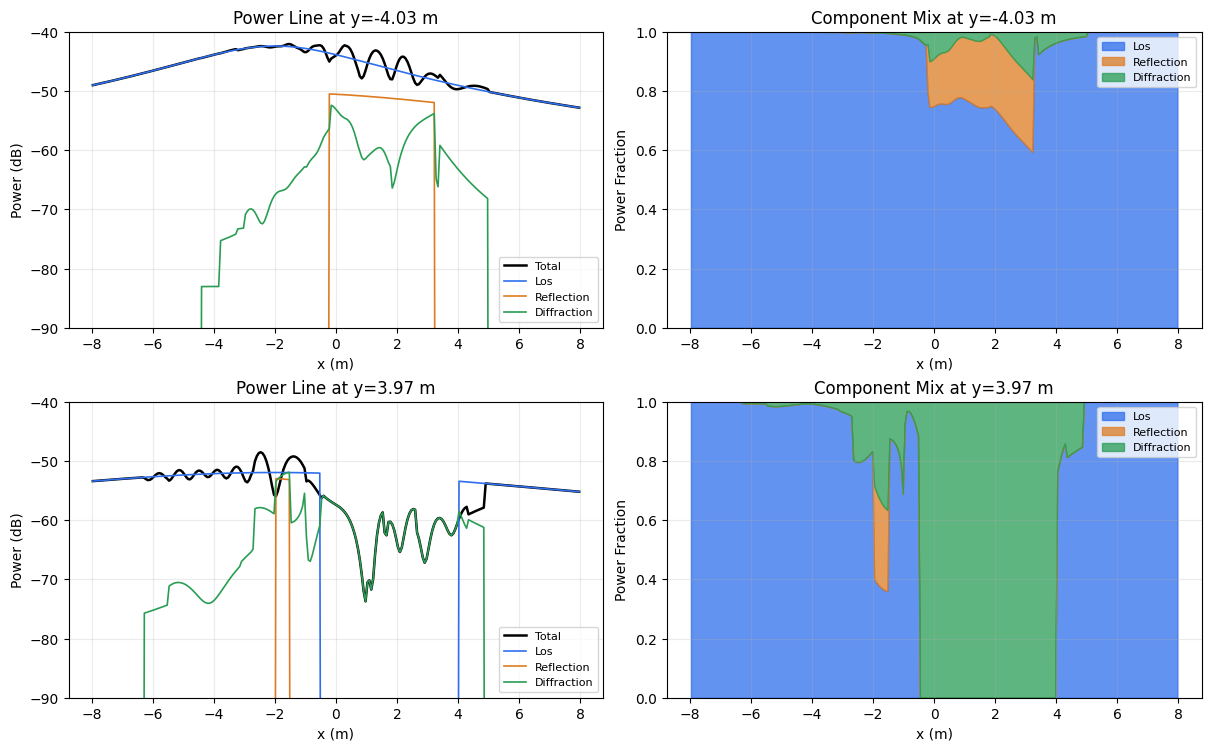

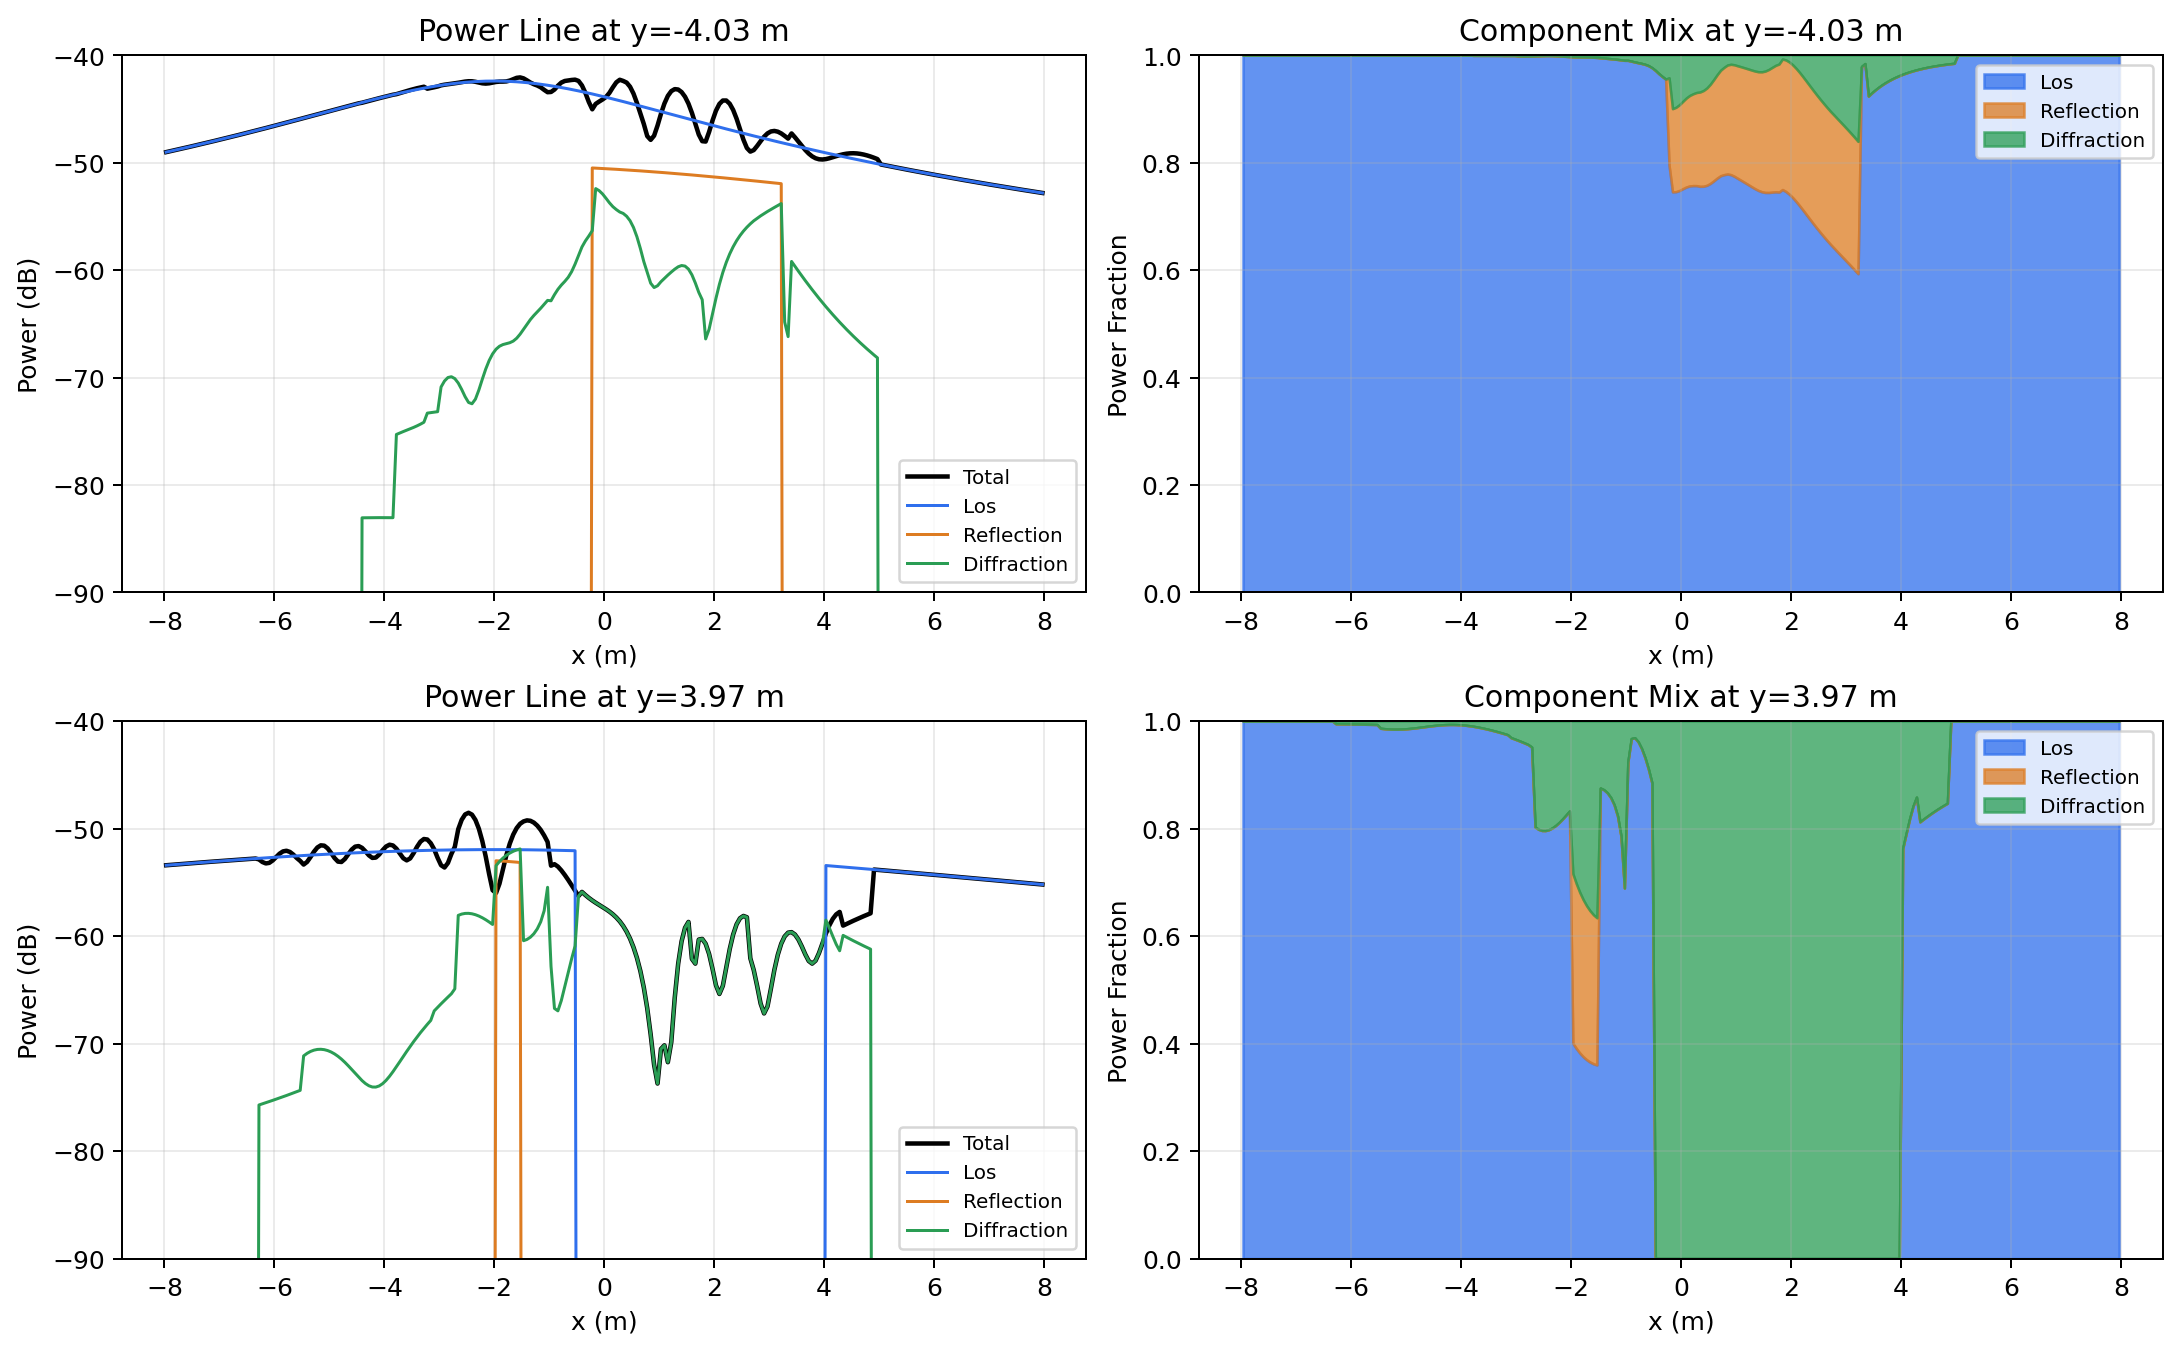

In [6]:
axes = single_cube.plot_line_power_profiles(line_profiles)
axes[0, 0].figure.savefig(line_profiles_path, dpi=180, bbox_inches="tight")
plt.show()

display(Image(filename=str(line_profiles_path)))
